In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt


In [39]:

np.random.seed(42)

# Cluster 1 (purple / upper-left)
n1 = 50
x1 = np.random.normal(loc=-0.2, scale=0.6, size=n1)
y1 = np.random.normal(loc=0.7, scale=0.4, size=n1)

# Cluster 2 (yellow / lower-right)
n2 = 50
x2 = np.random.normal(loc=1.0, scale=0.6, size=n2)
y2 = np.random.normal(loc=-0.2, scale=0.4, size=n2)
X = np.vstack([
    np.column_stack([x1, y1]),
    np.column_stack([x2, y2])
])

y = np.array([0]*n1 + [1]*n2)


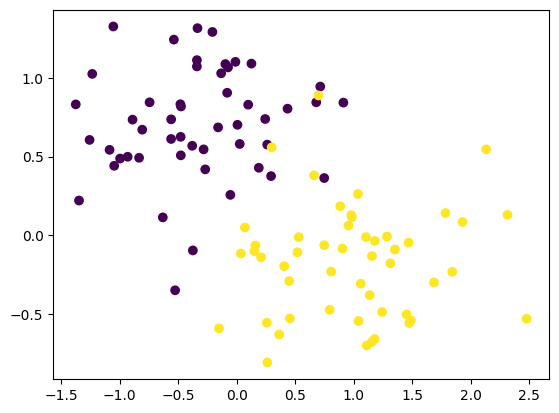

In [40]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.show()

In [41]:
model=Sequential([
    Input(shape=(2,)),
    Dense(10,activation='tanh',),
    Dense(10,activation='tanh',),
    Dense(10,activation='tanh',),
    Dense(10,activation='tanh',),
    Dense(1,activation='sigmoid',)
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.01),metrics=['accuracy'])
history=model.fit(X,y,validation_split=0.2,epochs=250)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.2875 - loss: 0.8794 - val_accuracy: 0.0000e+00 - val_loss: 0.7809
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8000 - loss: 0.5228 - val_accuracy: 0.8000 - val_loss: 0.5219
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9125 - loss: 0.3593 - val_accuracy: 0.9000 - val_loss: 0.3543
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9000 - loss: 0.2716 - val_accuracy: 0.9000 - val_loss: 0.2907
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9000 - loss: 0.2171 - val_accuracy: 0.9000 - val_loss: 0.2524
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9125 - loss: 0.1882 - val_accuracy: 0.9000 - val_loss: 0.2236
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9500 - loss: 0.1641 - val_accuracy: 0.9000 - val_loss: 0.1670
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9500 - loss: 0.1443 - val_accuracy: 0.9500 - val_l

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 4s 433us/step


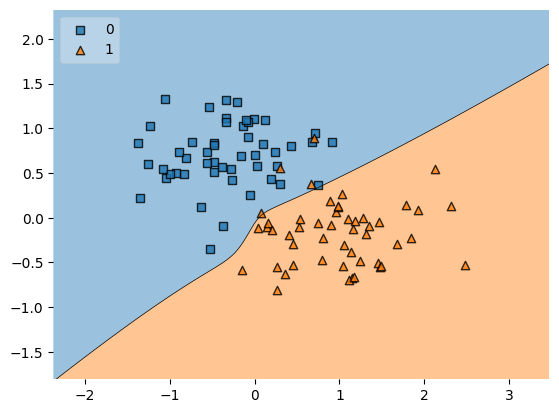

In [43]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype(int),clf=model,legend=2)
plt.show()

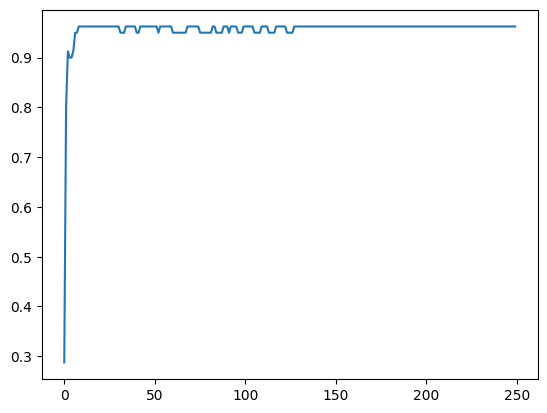

In [44]:
plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])

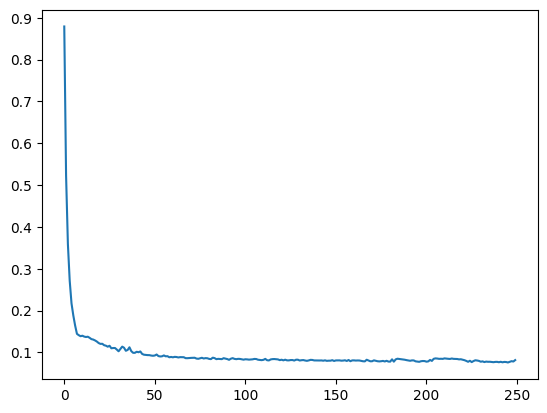

In [45]:
plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])

In [46]:
model.get_weights()

[array([[ 0.3243747 , -0.8639969 ,  0.11009242,  0.89609337, -0.39706734,
         -1.1760864 ,  0.7962566 ,  0.80725336, -0.44476458, -0.2680263 ],
        [ 0.47340137, -0.28167436,  0.8179248 ,  0.07138503,  0.48394924,
         -0.12391506, -0.37166843, -0.7272512 ,  0.672262  ,  0.9306123 ]],
       dtype=float32),
 array([ 0.02572514, -0.05402897, -0.1148876 , -0.11491851, -0.00058468,
        -0.02487949,  0.08495022, -0.0600767 ,  0.10898882,  0.01492355],
       dtype=float32),
 array([[-0.34957415, -0.40912068,  0.26503032, -0.35639393, -0.06400814,
         -0.10777368,  0.33153746,  0.4013935 ,  0.2667377 ,  0.42611796],
        [ 0.09452255,  0.7591513 , -0.5185213 ,  0.17435578,  0.74000007,
          0.19984768,  0.5091032 ,  0.0099781 , -0.37129033,  0.05862062],
        [-0.1665524 ,  0.01889929,  0.17746831, -0.7529531 ,  0.07893386,
          0.20217505,  0.4726627 ,  0.19746035, -0.4350885 ,  0.5330757 ],
        [-0.28823203, -0.93954647, -0.01289015,  0.6262607 , 

In [47]:
initial_weights = model.get_weights()
initial_weights[0] = np.random.randn(*initial_weights[0].shape) * np.sqrt(1 / 2)
initial_weights[1] = np.zeros_like(initial_weights[1])

initial_weights[2] = np.random.randn(*initial_weights[2].shape) * np.sqrt(1 / 10)
initial_weights[3] = np.zeros_like(initial_weights[3])

initial_weights[4] = np.random.randn(*initial_weights[4].shape) * np.sqrt(1 / 10)
initial_weights[5] = np.zeros_like(initial_weights[5])

initial_weights[6] = np.random.randn(*initial_weights[6].shape) * np.sqrt(1 / 10)
initial_weights[7] = np.zeros_like(initial_weights[7])

initial_weights[8] = np.random.randn(*initial_weights[8].shape) * np.sqrt(1 / 10)
initial_weights[9] = np.zeros_like(initial_weights[9])


In [48]:
model.set_weights(initial_weights)

In [49]:
model.get_weights()

[array([[ 0.25299388,  0.39653453,  0.7658329 ,  0.74515057, -0.97415936,
         -0.66314244,  0.36418492,  0.36330152,  0.3641937 ,  2.7242925 ],
        [ 0.40368056,  0.8029662 ,  0.6745811 ,  0.46060318, -0.22292902,
          0.5366723 , -0.5464699 , -0.16745605, -0.34320384,  0.05789376]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.7319593 , -0.5904811 ,  0.21701452, -0.50998557, -0.14923796,
          0.34435642,  0.02032713, -0.34081283, -0.2261989 ,  0.21490768],
        [-0.2309622 ,  0.06845022,  0.01441108, -0.20605412,  0.67797464,
          0.2004628 , -0.6404063 ,  0.05896203, -0.20927526,  0.26956308],
        [-0.25061706, -0.03628285,  0.159691  ,  0.27377585, -0.37956706,
         -0.10577857, -0.15019089, -0.20660084,  0.55828565,  0.12806647],
        [-0.39872652,  0.29025343,  0.6710847 ,  0.3264942 , -0.48046696,
         -0.15312827,  0.40063247, -0.22378473,  0.14034803,  0.2449608 ],
        [-0.29312

In [50]:
model.compile(loss='binary_crossentropy',optimizer=Adam(learning_rate=0.01),metrics=['accuracy'])
history=model.fit(X,y,validation_split=0.2,epochs=250)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.1750 - loss: 0.8280 - val_accuracy: 0.0000e+00 - val_loss: 0.7498
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7750 - loss: 0.5981 - val_accuracy: 0.8500 - val_loss: 0.6183
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9250 - loss: 0.4720 - val_accuracy: 0.9000 - val_loss: 0.4961
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9125 - loss: 0.3791 - val_accuracy: 0.9000 - val_loss: 0.3722
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9250 - loss: 0.3012 - val_accuracy: 0.9000 - val_loss: 0.2923
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9375 - loss: 0.2489 - val_accuracy: 0.9000 - val_loss: 0.2525
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9375 - loss: 0.2024 - val_accuracy: 0.9000 - val_loss: 0.2182
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9625 - loss: 0.1802 - val_accuracy: 0.9000 - val_l

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 4s 433us/step


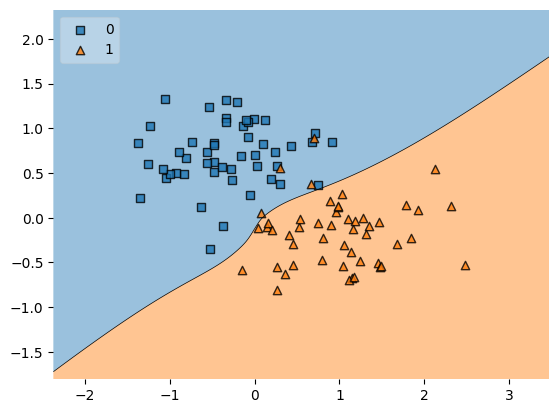

In [51]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype(int),clf=model,legend=2)
plt.show()

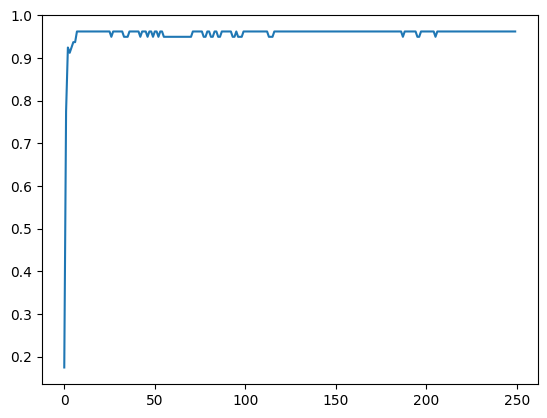

In [52]:
plt.plot(history.history['accuracy'])
# plt.plot(history.history['val_accuracy'])

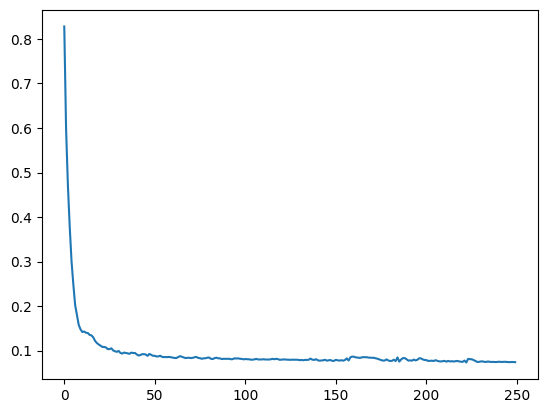

In [53]:
plt.plot(history.history['loss'])
# plt.plot(history.history['val_loss'])